<a href="https://colab.research.google.com/github/AlisaLeibova/ML-study/blob/main/Copy_of_HW_2_2_%D0%9B%D0%BE%D0%B3%D1%96%D1%81%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B7_scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [73]:
import pandas as pd
train_csv = pd.read_csv("train.csv")
train_csv.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [74]:
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB



*   Нема пропущенних значень
*   3 типи даних - int, float, object
*   15 тис даних, 14 столбців







In [75]:
train_csv.shape

(15000, 14)

In [76]:
from sklearn.model_selection import train_test_split
target_col = 'Exited'
train_df, val_df = train_test_split(train_csv, test_size=0.25, stratify=train_csv[target_col], random_state=42)

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [77]:
id_col = 'id'
drop_cols = ['CustomerId', 'Surname', 'Exited','id']
target_col = 'Exited'

input_cols = [col for col in train_df.columns if col not in drop_cols]

In [78]:
train_ids = train_df[id_col].copy()
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [79]:
val_ids = val_df[id_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [80]:
import numpy as np
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
numeric_cols

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

In [81]:
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()
categorical_cols

['Geography', 'Gender']

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [82]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00
mean,658.99,37.69,5.02,42952.89,1.59,0.79,0.49,117904.96
std,72.12,8.14,2.78,59923.39,0.53,0.41,0.50,45553.03
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83155.87
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123587.94
75%,709.00,42.00,7.00,109863.19,2.00,1.00,1.00,156774.94
max,850.00,72.00,10.00,209767.31,4.00,1.00,1.00,199992.48


Давайте використаємо MinMaxScaler з sklearn.preprocessing, щоб масштабувати значення до діапазону  (0,1) .

In [83]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [84]:
scaler.fit(train_inputs[numeric_cols])

MinMaxScaler()

In [85]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

In [86]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00
mean,0.54,0.36,0.50,0.20,0.20,0.79,0.49,0.59
std,0.17,0.15,0.28,0.29,0.18,0.41,0.50,0.23
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.41,0.26,0.30,0.00,0.00,1.00,0.00,0.42
50%,0.55,0.35,0.50,0.00,0.33,1.00,0.00,0.62
75%,0.66,0.44,0.70,0.52,0.33,1.00,1.00,0.78
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


Кодування категоріальних даних

In [87]:
train_inputs[categorical_cols].nunique()

,0
Geography,3
Gender,2


In [92]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_inputs[categorical_cols])
encoder.categories_

[array(['France', 'Germany', 'Spain'], dtype=object),
 array(['Female', 'Male'], dtype=object)]

In [93]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
print(encoded_cols)

['Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


In [94]:
encoder.transform(train_inputs[categorical_cols])[:10]
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])


In [95]:
display(train_inputs.head())
display(val_inputs.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
8263,0.632458,France,Male,0.259259,0.5,0.622726,0.000000,1.0,1.0,0.433916,1.0,0.0,0.0,0.0,1.0
14199,0.479714,Germany,Female,0.259259,0.4,0.571232,0.000000,1.0,0.0,0.888712,0.0,1.0,0.0,1.0,0.0
1856,0.591885,France,Female,0.074074,0.4,0.000000,0.333333,1.0,1.0,0.813017,1.0,0.0,0.0,1.0,0.0
3013,0.653938,France,Male,0.555556,0.3,0.000000,0.333333,1.0,0.0,0.599071,1.0,0.0,0.0,0.0,1.0
8266,0.632458,France,Female,0.314815,0.7,0.000000,0.333333,1.0,0.0,0.502109,1.0,0.0,0.0,1.0,0.0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
1855,0.267303,France,Male,0.203704,0.9,0.570579,0.0,0.0,0.0,0.279047,1.0,0.0,0.0,0.0,1.0
1273,0.398568,Germany,Male,0.425926,0.3,0.590481,0.0,1.0,0.0,0.884371,0.0,1.0,0.0,0.0,1.0
5414,0.453461,France,Male,0.240741,0.7,0.000000,0.0,1.0,1.0,0.751226,1.0,0.0,0.0,0.0,1.0
10923,0.396181,France,Male,0.703704,0.3,0.000000,1.0,1.0,0.0,0.514675,1.0,0.0,0.0,0.0,1.0
5835,0.758950,Spain,Female,0.444444,0.5,0.000000,0.0,1.0,1.0,0.909003,0.0,0.0,1.0,1.0,0.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [96]:
!pip install pyarrow --quiet

In [23]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

In [97]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (11250, 15)
train_targets: (11250,)
val_inputs: (3750, 15)
val_targets: (3750,)


In [27]:
import os

your_dir = '/content/Kaggle (train+test)'
print(os.listdir(your_dir))

['val_targets.parquet', 'train_inputs.parquet', 'val_inputs.parquet', 'train_targets.parquet']


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [122]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear',class_weight='balanced',random_state=42)
feature_cols = numeric_cols + encoded_cols
X_train = train_inputs[feature_cols]
X_val = val_inputs[feature_cols]
model.fit(X_train, train_targets)

LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')

In [101]:
print(model.coef_.tolist())

[[-0.8249488893476326, 8.658474888966436, -0.08278804216712987, -0.8131766842287218, -3.276552685153646, -0.1734987669874446, -1.074676514368546, 0.1668161329606492, -0.7906284961711235, 0.7314575109491587, -0.8786947975372867, -0.01326844602570342, -0.924597336733966]]


In [102]:
print(model.intercept_)

[-0.93786578]


7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [103]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

AUROC for Training: 0.88


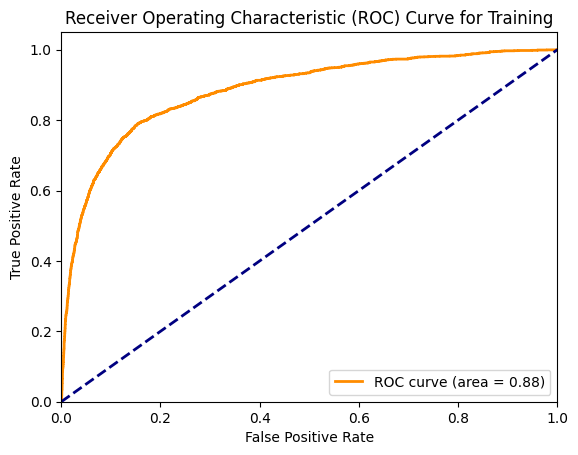

AUROC for Validation: 0.88


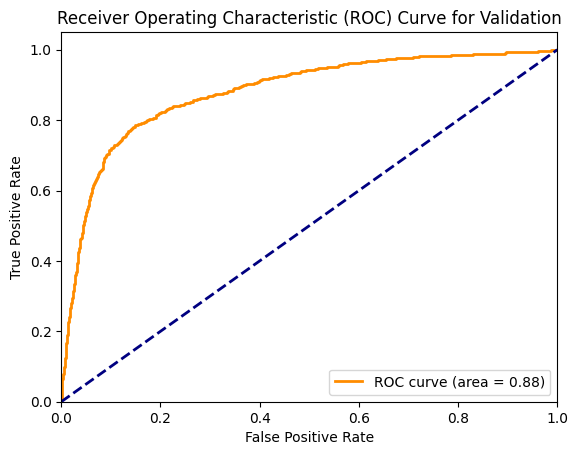

In [104]:
def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1.0)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

In [132]:
from sklearn.metrics import f1_score

def get_f1_score(inputs, targets, name=''):
    proba = model.predict_proba(inputs)[:, 1]
    preds = (proba >= 0.6).astype(int)
    f1 = f1_score(targets, preds, pos_label=1.0)
    print(f"F1 score {name}: {f1:.2f}")

get_f1_score(X_train, train_targets, 'Training')
get_f1_score(X_val, val_targets, 'Validation')

F1 score Training: 0.67
F1 score Validation: 0.67


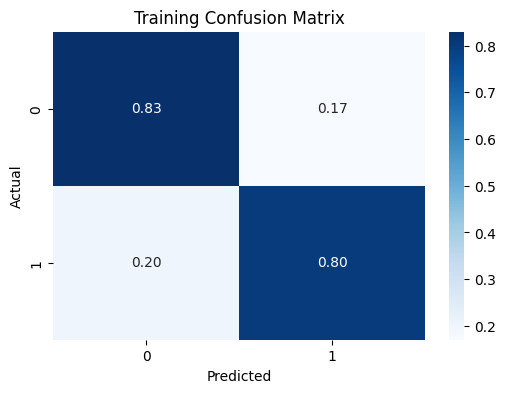

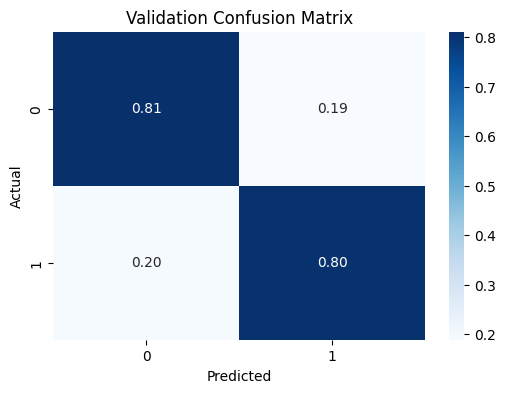

In [133]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(inputs, targets, name=''):
    preds = model.predict(inputs)
    cm = confusion_matrix(targets, preds, normalize='true')

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

plot_confusion_matrix(X_train, train_targets, 'Training')
plot_confusion_matrix(X_val, val_targets, 'Validation')

Mодель виглядає як добра базова модель: вона стабільно працює на train і validation, добре ранжує класи та вже дає непоганий баланс помилок.
Зараз головний резерв-не стільки змінювати модель, скільки акуратно підібрати поріг і порівняти F1, precision та recall.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [134]:
from sklearn.metrics import accuracy_score
import numpy as np

majority_class = train_targets.mode()[0]

train_majority_preds = np.full(len(train_targets), majority_class)
val_majority_preds = np.full(len(val_targets), majority_class)

train_model_preds = model.predict(X_train)
val_model_preds = model.predict(X_val)

print("Majority class:", majority_class)
print("Accuracy majority model on train:", accuracy_score(train_targets, train_majority_preds))
print("Accuracy majority model on val:", accuracy_score(val_targets, val_majority_preds))
print("Accuracy our model on train:", accuracy_score(train_targets, train_model_preds))
print("Accuracy our model on val:", accuracy_score(val_targets, val_model_preds))

Majority class: 0.0
Accuracy majority model on train: 0.7965333333333333
Accuracy majority model on val: 0.7965333333333333
Accuracy our model on train: 0.8236444444444444
Accuracy our model on val: 0.8098666666666666


Порівняння з базовою моделлю, яка завжди передбачає мажоритарний клас, показало, що наша модель дає вищий Accuracy на train і validation. Отже, вона навчається не просто відтворювати частий клас, а знаходить корисні закономірності в даних.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [135]:
import joblib


joblib.dump(
    {
        'model': model,
        'scaler': scaler,
        'encoder': encoder,
        'numeric_cols': numeric_cols,
        'categorical_cols': categorical_cols,
        'feature_cols': feature_cols
    },
    'logreg_bundle.joblib'
)
joblib.dump(model, 'log_reg.joblib')
model_2 = joblib.load('log_reg.joblib')

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [136]:
def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, raw_df):
    input_df = raw_df.copy()

    scaled_numeric = pd.DataFrame(
        scaler.transform(input_df[numeric_cols]),
        columns=numeric_cols,
        index=input_df.index
    )

    encoded_categorical = pd.DataFrame(
        encoder.transform(input_df[categorical_cols]),
        columns=encoder.get_feature_names_out(categorical_cols),
        index=input_df.index
    )

    X_input = pd.concat([scaled_numeric, encoded_categorical], axis=1)

    return model.predict_proba(X_input)[:, 1]

In [137]:
predict_raw_df(
    scaler, encoder,
    numeric_cols, categorical_cols,
    train_df[input_cols].head()
)

array([0.06576628, 0.75147585, 0.02132082, 0.60518623, 0.3148445 ])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [138]:
test_raw_df = pd.read_csv('test.csv')

test_raw_df['Exited'] = predict_raw_df(
    scaler=scaler,
    encoder=encoder,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    raw_df=test_raw_df
)

test_raw_df[['id', 'Exited']].head()

,id,Exited
0,15000,0.230169
1,15001,0.136145
2,15002,0.404409
3,15003,0.472826
4,15004,0.208113


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [140]:
sample_submission = pd.read_csv('sample_submission.csv')

submission = test_raw_df[['id', 'Exited']].copy()

assert submission.shape[0] == sample_submission.shape[0]
assert submission.columns.tolist() == sample_submission.columns.tolist()
assert submission['Exited'].between(0, 1).all()

submission.to_csv('submission_logreg.csv', index=False)

display(submission.head())
print(submission.shape)

,id,Exited
0,15000,0.230169
1,15001,0.136145
2,15002,0.404409
3,15003,0.472826
4,15004,0.208113


(10000, 2)
